1. In your first .ipynb or .py file called **initial_analysis** complete the following steps:
     1. Load the Foreign Gifts data.
     2. Describe the differences between different classes of gift types.
     3. Answer the following questions:
         1. Which country gives the most money in total?
         2. Which country initiates the most gifts by count?
         3. Which country gives the largest gifts on average?
         4. Which institution receive the most money in total?
         5. Which institution receive the greatest number of gifts by count?
         6. What is the average amount each university receives? Median amount? If they are different why?
         7. What is the largest flow of a single country to a single institution?
         8. Which are the top giftors to US academic institutions?

## 1. Load Foreign Gifts data

In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)

df.head()
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28221 entries, 0 to 28220
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          28221 non-null  int64
 1   OPEID                       28221 non-null  int64
 2   Institution Name            28221 non-null  str  
 3   City                        28221 non-null  str  
 4   State                       28221 non-null  str  
 5   Foreign Gift Received Date  28221 non-null  int64
 6   Foreign Gift Amount         28221 non-null  int64
 7   Gift Type                   28221 non-null  str  
 8   Country of Giftor           28221 non-null  str  
 9   Giftor Name                 24470 non-null  str  
dtypes: int64(4), str(6)
memory usage: 2.2 MB


## 2. Describe the differences between different classes of gift types.

In [16]:
df['Gift Type'].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

In [18]:

df.groupby('Gift Type')['Foreign Gift Amount'].agg(['mean','median'])

,mean,median
Gift Type,,
Contract,6.257945e+05,110000.0
Monetary Gift,5.281504e+05,50000.0
Real Estate,1.335265e+06,667555.0


- There are three different types of gifts: a contract, monetary gift, and real estate. The average Foreign Gift amount is the highest among the Real Estate gift type, followed by Contract, and then Monetary Gift, which has the lowest average. Contract is the most common gift type given and Real Estate is the least common gift type given. 

## 3. Answer the following questions:

3. 1. Which country gives the most money in total?
- Qatar gives the most money in total.

In [21]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
                   ...    
IRAN                    80
ST. LUCIA               50
CROATIA                 26
SLOVAKIA                20
ERITREA                  3
Name: Foreign Gift Amount, Length: 155, dtype: int64

3. 2. Which country initiates the most gifts by count?
- England initiates the most gifts by count.

In [22]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
                   ... 
ST. LUCIA             1
TOKELAU               1
SLOVAKIA              1
ST. KITTS-NEVIS       1
TUNISIA               1
Name: Foreign Gift Amount, Length: 155, dtype: int64

3. 3. Which country gives the largest gifts on average?
- Bermuda gives the largest gifts on average.

In [23]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().sort_values(ascending=False)

Country of Giftor
BERMUDA      7.688837e+06
ECUADOR      3.985140e+06
QATAR        3.905109e+06
ANTIGUA      3.435545e+06
JERSEY       3.064589e+06
                 ...     
ST. LUCIA    5.000000e+01
IRAN         4.000000e+01
CROATIA      2.600000e+01
SLOVAKIA     2.000000e+01
ERITREA      3.000000e+00
Name: Foreign Gift Amount, Length: 155, dtype: float64

3. 4. Which institution receive the most money in total?
- Carnegie Mellon University receives the most money in total.

In [25]:
df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
                                            ...    
Jacksonville State University                250000
Metropolitan State University                235439
University of California, Merced             182514
University of Central Oklahoma               160288
University of Jamestown                         500
Name: Foreign Gift Amount, Length: 318, dtype: int64

3. 5. Which institution receive the greatest number of gifts by count?
- The University of California, Los Angeles receives the greatest number of gifts by count.

In [30]:
df.groupby('Institution Name')['Foreign Gift Amount'].count().sort_values(ascending=False)

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
                                               ... 
Washington Adventist University                   1
Western Oregon University                         1
Wesleyan College                                  1
Wayne State University                            1
Yeshiva University                                1
Name: Foreign Gift Amount, Length: 318, dtype: int64

** Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. **

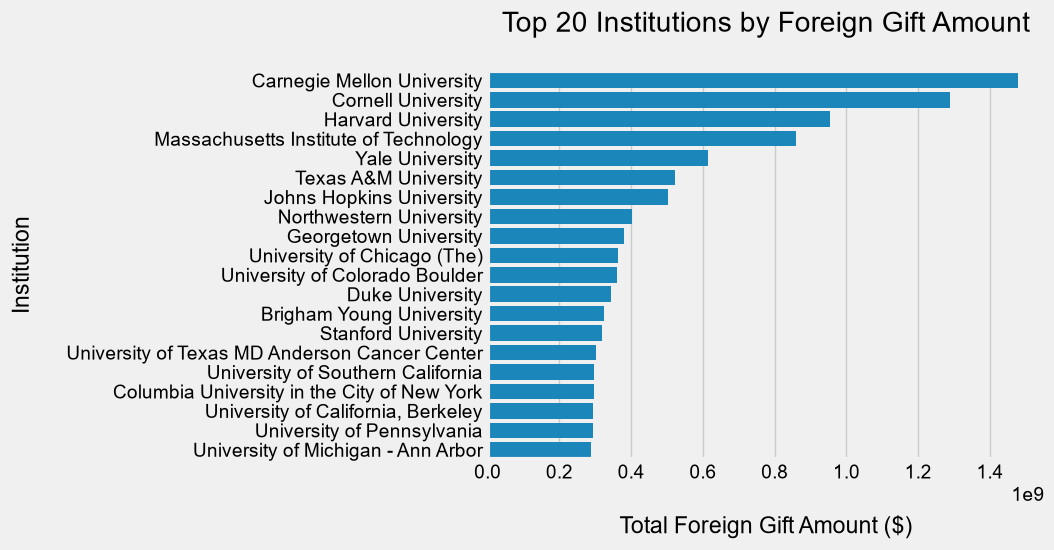

In [138]:
top_20_uni = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(20)
top_20_uni = pd.DataFrame(top_20_uni).reset_index()

sns.barplot(
    data=top_20_uni,
    x='Foreign Gift Amount',
    y='Institution Name'
)

plt.title('Top 20 Institutions by Foreign Gift Amount\n')
plt.xlabel('\nTotal Foreign Gift Amount ($)')
plt.ylabel('Institution\n')
plt.style.use('bmh')


3. 6. What is the average amount each university receives? Median amount? If they are different why?
- The average amount that each university receives is $52,202,880 and the median amount is $6,486,792, so the distribution is skewed to the right. The mean is likely much higher than the median due to the fact that there are a small number of universities that receive extremely large amounts, while a typical university likely receives much less. These outlier universities with these larger amounts are therefore pulling the mean up, while the median is not as affected by those more extreme cases.

**Plot a histogram of the amounts received by each university, and then label the median and the mean as vertical lines.**

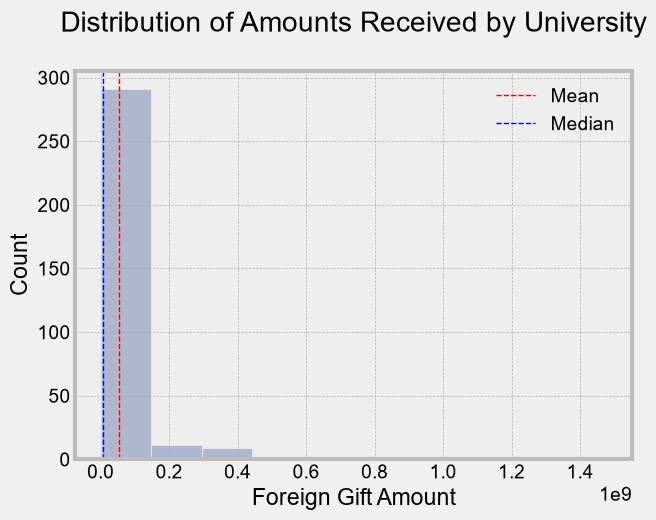

In [139]:
sns.histplot(uni_amounts, bins=10, color='#97a6c4')

plt.axvline(uni_amounts.mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(uni_amounts.median(), color='blue', linestyle='dashed', linewidth=1, label='Median')
plt.title('Distribution of Amounts Received by University\n')
plt.style.use('grayscale')
plt.legend()


In [46]:
uni_amounts = df.groupby('Institution Name')['Foreign Gift Amount'].sum()
uni_amounts.agg(['mean','median'])


mean      5.220288e+07
median    6.486792e+06
Name: Foreign Gift Amount, dtype: float64

3. 7. What is the largest flow of a single country to a single institution?
- The largest flow of a single country to a single institution is from Qatar to Cornell University.

In [135]:
country_flow_to_institution = df.groupby(["Country of Giftor", "Institution Name"])["Foreign Gift Amount"].sum().sort_values(ascending=False)

country_flow_to_institution.head()

Country of Giftor  Institution Name          
QATAR              Cornell University            1018473315
BERMUDA            Carnegie Mellon University     750000000
QATAR              Texas A&M University           504099350
                   Carnegie Mellon University     425410702
                   Georgetown University          327128310
Name: Foreign Gift Amount, dtype: int64

In [85]:
pd.crosstab(df["Country of Giftor"], df["Institution Name"])

Institution Name,Adelphi University,Albert Einstein College of Medicine,Alfred University,American University (The),Amherst College,Arizona State University,Auburn University Montgomery,Babson College,Ball State University,Barnard College,...,Wilkes University,William Marshall Rice University,Williams College,Winthrop University,Worcester Polytechnic Institute,Wright State University,Xavier University of Louisiana,Yale University,Yeshiva University,Young Americans College of the Performing Arts (The)
Country of Giftor,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AMERICAN SAMOA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANGOLA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANTIGUA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ARGENTINA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGIN ISLANDS (BRITISH),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
WALES,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
YEMEN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
df.groupby(['Institution Name','Country of Giftor'])['Foreign Gift Amount'].sum().sort_values(ascending=False)

Institution Name                       Country of Giftor   
Cornell University                     QATAR                   1018473315
Carnegie Mellon University             BERMUDA                  750000000
Texas A&M University                   QATAR                    504099350
Carnegie Mellon University             QATAR                    425410702
Georgetown University                  QATAR                    327128310
                                                                  ...    
Johns Hopkins University               CAYMAN ISLANDS (THE)            10
Westminster Theological Seminary       TRINIDAD                        10
                                       UNITED NATIONS                  10
University of California, Los Angeles  ERITREA                          3
University of California, Merced       MEXICO                           1
Name: Foreign Gift Amount, Length: 2685, dtype: int64

3. 8. Which are the top giftors to US academic institutions?
- The top giftor names by the number of gifts to US academic institutions are Saudi Arabia Cultural Mission, Human Frontier Science Program, and Anonymous. The top giftor names by the total gift amount are Qatar Foundation, Qatar Foundation/Qatar National Research Fund, and Qatar Foundation for Education. The top giftors based on country 

In [ ]:
top_giftors_amount = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)

top_giftors_amount.head()


Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
Name: Foreign Gift Amount, dtype: int64

In [128]:

top_giftors_count = df.groupby('Giftor Name')['Foreign Gift Amount'].count().sort_values(ascending=False)

top_giftors_count.head()

Giftor Name
Saudi Arabian Cultural Mission    480
Human Frontier Science Program    287
Anonymous                         262
Qatar Foundation                  261
Novartis Pharmaceuticals Corp     251
Name: Foreign Gift Amount, dtype: int64

To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an alluvial diagram. There is a built-in version in the plotly package that we'll use:

In [ ]:
df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

Bonus: Plot the flows from giftors to institutions.

**Plot showing the flows from giftors to institutions**

In [132]:
giftor = 'Giftor Name'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()